In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from lazypredict import LazyRegressor

In [2]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)


In [3]:
# load raw data

#df_raw = pd.read_csv('food_prediction_raw.csv')
df_raw = pd.read_csv('df_cleaned.csv', index_col=0)
df_raw.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,14,52062,7.541667,16.5,78.625,E,Clear,0.0,64.458333,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 731228 entries, 0 to 731227
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 731228 non-null  str    
 1   category_name        731228 non-null  str    
 2   item_id              731228 non-null  int64  
 3   sold_quantity        731228 non-null  float64
 4   price                731228 non-null  float64
 5   revenue              731228 non-null  float64
 6   store_id             731228 non-null  int64  
 7   month                731228 non-null  int64  
 8   day_of_week          731228 non-null  int64  
 9   week                 731228 non-null  int64  
 10  zipcode              731228 non-null  int64  
 11  temperature          731228 non-null  float64
 12  wind_speed           731228 non-null  float64
 13  wind_degree          731228 non-null  float64
 14  wind_dir             731228 non-null  str    
 15  weather_description  731228 

## Creating Lag Features

__Issue__: No continuous time range__
+ If an item is not sold on a certain date/store there is ==no record== and thus no date. That breaks the date range

__Solution:__ we first have to create a consecutive date range, to get correct lag features afterwards.
+ Lags:
    * t-1 
    * t-3
    * t-7
    * ~~t-14~~

In [5]:
# sort new copy in preperation for correct lag features
df = df_raw.sort_values(['store_id', 'item_id', 'date']).copy()

# convert date
df['date'] = pd.to_datetime(df.date)

# deleting cols month, day_of_week, week for now  --> because after reindexing we have new rows of these cols with NaN --> we add them later again after reindexing
df = df.drop(columns=['month', 'day_of_week', 'week'])

df.head()

,date,category_name,item_id,sold_quantity,price,revenue,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
37918,2025-04-05,Kuchen,1,0.0,12.00,0.00,0,52062,11.916667,14.333333,51.833333,NE,Sunny,0.000000,59.875000,10.000000,1017.666667,13.583333,3.833333,21.916667,2.625000,520622025-04-05,0,0,0
99085,2025-04-12,Kuchen,1,0.0,12.00,0.00,0,52062,14.208333,13.833333,139.875000,SE,Sunny,0.004167,60.583333,10.000000,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0,1,0
252700,2025-05-03,Kuchen,1,0.0,12.00,0.00,0,52062,13.416667,8.583333,264.500000,WNW,Light rain shower,0.270833,91.333333,8.291667,1011.583333,68.583333,12.041667,12.833333,2.250000,520622025-05-03,0,0,0
374345,2025-05-17,Kuchen,1,1.0,11.25,11.25,0,52062,11.541667,8.500000,304.375000,N,Sunny,0.000000,71.291667,8.000000,1019.375000,24.750000,5.916667,12.750000,2.666667,520622025-05-17,0,0,0
435176,2025-05-24,Kuchen,1,1.0,11.25,11.25,0,52062,10.125000,19.666667,214.250000,SSW,Partly cloudy,0.166667,74.833333,8.916667,1016.458333,78.125000,5.541667,30.750000,2.000000,520622025-05-24,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 731228 entries, 37918 to 731128
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 731228 non-null  datetime64[us]
 1   category_name        731228 non-null  str           
 2   item_id              731228 non-null  int64         
 3   sold_quantity        731228 non-null  float64       
 4   price                731228 non-null  float64       
 5   revenue              731228 non-null  float64       
 6   store_id             731228 non-null  int64         
 7   zipcode              731228 non-null  int64         
 8   temperature          731228 non-null  float64       
 9   wind_speed           731228 non-null  float64       
 10  wind_degree          731228 non-null  float64       
 11  wind_dir             731228 non-null  str           
 12  weather_description  731228 non-null  str           
 13  precip               73122

In [7]:
df = df.set_index(['store_id', 'item_id', 'date'])
df.head(15)

category_name  sold_quantity  price  revenue  \
store_id item_id date                                                      
0        1       2025-04-05        Kuchen            0.0  12.00     0.00   
                 2025-04-12        Kuchen            0.0  12.00     0.00   
                 2025-05-03        Kuchen            0.0  12.00     0.00   
                 2025-05-17        Kuchen            1.0  11.25    11.25   
                 2025-05-24        Kuchen            1.0  11.25    11.25   
                 2025-06-07        Kuchen            0.0  12.00     0.00   
                 2025-06-28        Kuchen            0.0  12.00     0.00   
         7       2025-04-01      Brötchen            9.0   0.70     6.30   
                 2025-04-02      Brötchen            3.0   0.70     2.10   
                 2025-04-03      Brötchen           13.0   0.70     9.10   
                 2025-04-04      Brötchen            2.0   0.70     1.40   
                 2025-04-05      Brötchen           18.0   0.70    12.60   
                 2025-04-07      Brötchen            7.0   0.70     4.90   
                 2025-04-08      Brötchen            2.0   0.70     1.40   
                 2025-04-11      Brötchen           12.0   0.70     8.40   

                             zipcode  temperature  wind_speed  wind_degree  \
store_id item_id date                                                        
0        1       2025-04-05    52062    11.916667   14.333333    51.833333   
                 2025-04-12    52062    14.208333   13.833333   139.875000   
                 2025-05-03    52062    13.416667    8.583333   264.500000   
                 2025-05-17    52062    11.541667    8.500000   304.375000   
                 2025-05-24    52062    10.125000   19.666667   214.250000   
                 2025-06-07    52062    13.500000   20.291667   225.166667   
                 2025-06-28    52062    22.541667   16.125000   259.125000   
         7       2025-04-01    52062     7.541667   16.500000    78.625000   
                 2025-04-02    52062     9.791667   22.083333    82.333333   
                 2025-04-03    52062    12.208333   17.291667   104.500000   
                 2025-04-04    52062    12.833333   11.291667    85.458333   
                 2025-04-05    52062    11.916667   14.333333    51.833333   
                 2025-04-07    52062     6.458333   10.166667    74.125000   
                 2025-04-08    52062     8.458333    8.750000    71.083333   
                 2025-04-11    52062    10.375000    6.500000   221.833333   

                            wind_dir   weather_description    precip  \
store_id item_id date                                                  
0        1       2025-04-05       NE                 Sunny  0.000000   
                 2025-04-12       SE                 Sunny  0.004167   
                 2025-05-03      WNW     Light rain shower  0.270833   
                 2025-05-17        N                 Sunny  0.000000   
                 2025-05-24      SSW         Partly cloudy  0.166667   
                 2025-06-07       SW  Patchy rain possible  0.208333   
                 2025-06-28        W                 Clear  0.000000   
         7       2025-04-01        E                 Clear  0.000000   
                 2025-04-02        E                 Clear  0.000000   
                 2025-04-03      ESE                 Sunny  0.000000   
                 2025-04-04      ESE                 Clear  0.000000   
                 2025-04-05       NE                 Sunny  0.000000   
                 2025-04-07      ESE                 Clear  0.000000   
                 2025-04-08      ESE                 Sunny  0.000000   
                 2025-04-11       NW                 Clear  0.000000   

                              humidity  visibility     pressure  cloudcover  \
store_id item_id date                                                         
0        1       2025-04-

In [8]:
df.sold_quantity.isna().sum()

np.int64(0)

In [9]:
# creating full date range for lags

all_dates = pd.date_range(df.index.get_level_values('date').min(), df.index.get_level_values('date').max(), freq='D')
all_stores = df.index.get_level_values('store_id').unique()
all_items = df.index.get_level_values('item_id').unique()

new_index = pd.MultiIndex.from_product([all_stores, all_items, all_dates],  names=['store_id', 'item_id', 'date'])

df = df.reindex(new_index)

# not neccessary, delete!
# filling NaN in target with 0 for training target must not be NaN
# df['sold_quantity'] = df['sold_quantity'].fillna(0)


In [10]:
# check
df.head(10)
#df.query('item_id == 7').head(20).info()

df.sold_quantity.isna().sum()

np.int64(3718672)

In [11]:
# creating lags

lags = [1, 3, 7]

for lag in lags:
    df[f'lag_{lag}'] = df.groupby(['store_id', 'item_id'])['sold_quantity'].shift({lag})
    


In [12]:
# check
#df.iloc[2000000:2000100]
#df.query('lag_1.notna() and item_id == 7').head(20)


## Creating Rolling Feature

__rollings__
* mean_7
* ~~mean_14~~
* median_7
+ difference between mean / median (when high value than more outliers)
+ ~~7-day trend~~
* sum_7
* std_7

In [13]:
# creating rollings

# reset for better handling
df = df.reset_index()

# less writing, -> shift(1) to exclude the current target value of the calculation of the mean/median/sum/std
shifted_group = df.groupby(['store_id', 'item_id'])['sold_quantity'].shift(1)

#...mean and median
df['rolling_mean_7'] = shifted_group.rolling(7).mean()
df['rolling_median_7'] = shifted_group.rolling(7).median()

# rolling mean 14 days back
# df['rolling_mean_14'] = shifted_group.rolling(14).mean()

# ...sum
df['rolling_sum_7'] = shifted_group.rolling(7).sum()

# ...std
df['rolling_std_7'] = shifted_group.rolling(7).std()

# last 7 day trend
# df['trend_7'] = df.rolling_mean_7 - df.rolling_mean_14 / (df['rolling_mean_14'] + 1e-8)

# mean median diff -> low == stable sold_qty, high == outliers
df['mean_median_diff_7'] = df['rolling_mean_7'] - df['rolling_median_7']

# reset multiindex
df = df.set_index(['store_id', 'item_id', 'date'])

In [14]:
# check
# print(df[['lag_1', 'lag_3', 'lag_7']].isna().sum().sum())
# print(len(df))

# gone = df[['lag_1', 'lag_3', 'lag_7']].isna().sum().sum() / len(df)
# print(gone)

df.isna().sum()

category_name          3718672
sold_quantity          3718672
price                  3718672
revenue                3718672
zipcode                3718672
temperature            3718672
wind_speed             3718672
wind_degree            3718672
wind_dir               3718672
weather_description    3718672
precip                 3718672
humidity               3718672
visibility             3718672
pressure               3718672
cloudcover             3718672
dewpoint               3718672
windgust               3718672
uv_index               3718672
date_zipcode           3718672
special_day            3718672
school_holiday         3718672
std_holiday            3718672
lag_1                  3727003
lag_3                  3740324
lag_7                  3777013
rolling_mean_7         4290792
rolling_median_7       4290792
rolling_sum_7          4290792
rolling_std_7          4290792
mean_median_diff_7     4290792
dtype: int64

In [15]:
# removing missing values in lag 1, 3, 7 at the beginning of each date/item time span.

lag_cols = ['lag_1', 'lag_3', 'lag_7']

# proportion of data loss after deleting rows where lags are missing
print('Data loss after removing NaN in lags:\n')
print(df[lag_cols].isna().sum() / df.shape[0])

# removing lags with missing values at the beginning (first 7 days)

df = df.dropna(subset=lag_cols)
print('-'*40)
print('--- removing missing values in lags... ---- ')
print('-'*40)
print('\nMissing values in lags after removing:\n')
print(df[lag_cols].isna().sum() / df.shape[0])



Data loss after removing NaN in lags:

lag_1    0.837548
lag_3    0.840541
lag_7    0.848786
dtype: float64
----------------------------------------
--- removing missing values in lags... ---- 
----------------------------------------

Missing values in lags after removing:

lag_1    0.0
lag_3    0.0
lag_7    0.0
dtype: float64


In [16]:
# remove all missing values
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 141818 entries, (np.int64(0), np.int64(22), Timestamp('2025-04-08 00:00:00')) to (np.int64(59), np.int64(876), Timestamp('2025-06-03 00:00:00'))
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category_name        141818 non-null  str    
 1   sold_quantity        141818 non-null  float64
 2   price                141818 non-null  float64
 3   revenue              141818 non-null  float64
 4   zipcode              141818 non-null  float64
 5   temperature          141818 non-null  float64
 6   wind_speed           141818 non-null  float64
 7   wind_degree          141818 non-null  float64
 8   wind_dir             141818 non-null  str    
 9   weather_description  141818 non-null  str    
 10  precip               141818 non-null  float64
 11  humidity             141818 non-null  float64
 12  visibility           141818 non-null  float64
 13  pressure     

## (Re-)Creating Temporal Features
from 'date'
* month
* week
* day_of_week


In [17]:
# check
pd.set_option('display.max_columns', None)



In [18]:
# reset multiindex first - otherwise .isocalender().week will not work
df = df.reset_index()

# new time features
df['month'] = df.date.dt.month
df['week'] = df.date.dt.isocalendar()['week']
df['day_of_week'] = df.date.dt.dayofweek

# setting back to mulitindex - not needed form here
#df = df.set_index(['store_id', 'item_id', 'date'])


In [19]:
df.head()

,store_id,item_id,date,category_name,sold_quantity,price,revenue,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week
0,0,22,2025-04-08,Brötchen,13.0,0.86,11.18,52062.0,8.458333,8.750000,71.083333,ESE,Sunny,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,520622025-04-08,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1
1,0,22,2025-04-09,Brötchen,7.0,0.90,6.30,52062.0,9.208333,9.625000,103.541667,N,Clear,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,520622025-04-09,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2
2,0,22,2025-04-10,Brötchen,11.0,0.90,9.90,52062.0,8.250000,9.625000,269.291667,NW,Clear,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,520622025-04-10,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3
3,0,22,2025-04-11,Brötchen,14.0,0.90,12.60,52062.0,10.375000,6.500000,221.833333,NW,Clear,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,520622025-04-11,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4
4,0,22,2025-04-12,Brötchen,5.0,0.81,4.05,52062.0,14.208333,13.833333,139.875000,SE,Sunny,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5


In [20]:
# check

# # needed for training: change non-numerical dtypes to ´category´
# cat_list = ['category_name', 'wind_dir', 'weather_description', 'date_zipcode']

# for col in cat_list:
#     df[col] = df[col].astype('category')


## __Create Train/Test Set__ - manually

In [21]:
# counting all days in the dataset
all_days = df['date'].nunique()

# 80 % for train set
days_for_train = int(all_days * 0.8)
days_for_test = all_days - days_for_train #int(all_days * 0.2)

# get date for split
start_date = df['date'].min()
end_date = df['date'].max()

split_date = start_date + pd.Timedelta(days=days_for_train)


# manual split

# 80 % train
train = df[df['date'] < split_date]

# 20 % test
test  = df[df['date'] >= split_date]

print('Train:', train.shape, train['date'].min(), train['date'].max())
print('Test:', test.shape, test['date'].min(), test['date'].max())

## reconsider

Train: (118358, 36) 2025-04-08 00:00:00 2025-06-13 00:00:00
Test: (23460, 36) 2025-06-14 00:00:00 2025-06-30 00:00:00


## __Encoding__
### Target Encoding


In [22]:
# check

df_raw.category_name.nunique()

21

In [23]:
# encoding 1

# target encoding .....for item per store, zipcode, store_id

#-------------

# fallback für test set
global_mean = train['sold_quantity'].mean()  # only for item_id per store


# traget encoding item_id (per store)
train['item_id_tar_enc'] = train.groupby(['store_id', 'item_id'])['sold_quantity'].shift(1).expanding().mean()

# last exp means item_id per store
last_item_id_mean = train.groupby(['store_id','item_id'])['item_id_tar_enc'].last()

# map last_mean to test set
test['item_id_tar_enc'] = test.apply(lambda row: last_item_id_mean.get((row['store_id'], row['item_id']), global_mean),axis=1)

#-------------

# target encoding per store_id
train['store_id_tar_enc'] = train.groupby(['store_id'])['sold_quantity'].shift(1).expanding().mean()

# last exp mean store_id
last_store_id_mean = train.groupby(['store_id'])['store_id_tar_enc'].last()

# map last_mean to test set
test['store_id_tar_enc'] = test.apply(lambda row: last_store_id_mean.get((row['store_id']), np.nan),axis=1)

#-------------

# target encoding zipcode
train['zipcode_tar_enc'] = train.groupby(['zipcode'])['sold_quantity'].shift(1).expanding().mean()

# last exp mean zipcode
last_zipcode_mean = train.groupby(['zipcode'])['zipcode_tar_enc'].last()

# map last_mean to test set
test['zipcode_tar_enc'] = test.apply(lambda row: last_zipcode_mean.get((row['zipcode']), np.nan),axis=1)

#-------------

# target encoding weather_description
train['weather_descr_tar_enc'] = train.groupby(['weather_description'])['sold_quantity'].shift(1).expanding().mean()

# last exp mean weather_description
last_weather_desc_mean = train.groupby(['weather_description'])['weather_descr_tar_enc'].last()

# map last_mean to test set
test['weather_descr_tar_enc'] = test.apply(lambda row: last_weather_desc_mean.get((row['weather_description']), np.nan),axis=1)

# add store...



In [24]:
# check 
test['item_id_tar_enc'].nunique()
test['item_id_tar_enc'].isna().sum()


np.int64(0)

In [25]:
# delete target encoded category cols
train = train.drop(columns=['zipcode', 'weather_description'], errors='ignore')
test = test.drop(columns=['zipcode', 'weather_description'], errors='ignore')



In [26]:
# check
train.head()

,store_id,item_id,date,category_name,sold_quantity,price,revenue,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc,store_id_tar_enc,zipcode_tar_enc,weather_descr_tar_enc
0,0,22,2025-04-08,Brötchen,13.0,0.86,11.18,8.458333,8.750000,71.083333,ESE,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,520622025-04-08,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1,NaN,NaN,NaN,NaN
1,0,22,2025-04-09,Brötchen,7.0,0.90,6.30,9.208333,9.625000,103.541667,N,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,520622025-04-09,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2,13.000000,13.000000,13.000000,NaN
2,0,22,2025-04-10,Brötchen,11.0,0.90,9.90,8.250000,9.625000,269.291667,NW,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,520622025-04-10,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3,10.000000,10.000000,10.000000,7.000000
3,0,22,2025-04-11,Brötchen,14.0,0.90,12.60,10.375000,6.500000,221.833333,NW,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,520622025-04-11,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4,10.333333,10.333333,10.333333,9.000000
4,0,22,2025-04-12,Brötchen,5.0,0.81,4.05,14.208333,13.833333,139.875000,SE,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5,11.250000,11.250000,11.250000,10.333333


### One Hot Encoding

In [27]:
# encoding 2
## One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

# instatiate encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# encode category_name  -  and apply to train and test set
train_cat_encoded = ohe.fit_transform(train[['category_name']])
test_cat_encoded = ohe.transform(test[['category_name']])

# make it a dataframe
df_train_cat_encoded = pd.DataFrame(train_cat_encoded, columns=(ohe.get_feature_names_out(['category_name'])), index=train.index)
df_test_cat_encoded = pd.DataFrame(test_cat_encoded, columns=(ohe.get_feature_names_out(['category_name'])), index=test.index)

# join with origin df
train = train.drop(columns=['category_name']).join(df_train_cat_encoded)
test = test.drop(columns=['category_name']).join(df_test_cat_encoded)




train.head()




,store_id,item_id,date,sold_quantity,price,revenue,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc,store_id_tar_enc,zipcode_tar_enc,weather_descr_tar_enc,category_name_Angebot Brot,category_name_Angebot Brötchen,category_name_Angebot Feinbäckerei,category_name_Angebot Heißgetränke,category_name_Angebot Kuchen,category_name_Angebot Snack,category_name_Brot,category_name_Brötchen,category_name_Eigerichte,category_name_Feinbäckerei,category_name_Heißgetränke,category_name_Kaltgetränke 19%,category_name_Kaltgetränke 7%,category_name_Konditorei,category_name_Kuchen,category_name_Printen/Kekse,category_name_Snack,category_name_Snack Belag
0,0,22,2025-04-08,13.0,0.86,11.18,8.458333,8.750000,71.083333,ESE,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,520622025-04-08,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,22,2025-04-09,7.0,0.90,6.30,9.208333,9.625000,103.541667,N,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,520622025-04-09,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2,13.000000,13.000000,13.000000,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,22,2025-04-10,11.0,0.90,9.90,8.250000,9.625000,269.291667,NW,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,520622025-04-10,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3,10.000000,10.000000,10.000000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,22,2025-04-11,14.0,0.90,12.60,10.375000,6.500000,221.833333,NW,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,520622025-04-11,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4,10.333333,10.333333,10.333333,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,22,2025-04-12,5.0,0.81,4.05,14.208333,13.833333,139.875000,SE,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,520622025-04-12,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5,11.250000,11.250000,11.250000,10.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# delete 3x wind + datezipcode....(?)
train = train.drop(columns=['wind_dir', 'wind_gust', 'wind_degree', 'wind_speed', 'date_zipcode'], errors='ignore')
test = test.drop(columns=['wind_dir', 'wind_gust', 'wind_degree', 'wind_speed', 'date_zipcode'], errors='ignore')
train.head()

,store_id,item_id,date,sold_quantity,price,revenue,temperature,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc,store_id_tar_enc,zipcode_tar_enc,weather_descr_tar_enc,category_name_Angebot Brot,category_name_Angebot Brötchen,category_name_Angebot Feinbäckerei,category_name_Angebot Heißgetränke,category_name_Angebot Kuchen,category_name_Angebot Snack,category_name_Brot,category_name_Brötchen,category_name_Eigerichte,category_name_Feinbäckerei,category_name_Heißgetränke,category_name_Kaltgetränke 19%,category_name_Kaltgetränke 7%,category_name_Konditorei,category_name_Kuchen,category_name_Printen/Kekse,category_name_Snack,category_name_Snack Belag
0,0,22,2025-04-08,13.0,0.86,11.18,8.458333,0.000000,58.375000,10.0,1026.875000,15.333333,0.416667,14.625000,2.291667,0.0,0.0,0.0,5.0,5.0,8.0,11.571429,8.0,81.0,12.634043,3.571429,4,15,1,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,22,2025-04-09,7.0,0.90,6.30,9.208333,0.000000,65.208333,10.0,1025.625000,25.375000,2.916667,14.625000,2.291667,0.0,0.0,0.0,13.0,40.0,9.0,12.285714,8.0,86.0,12.539462,4.285714,4,15,2,13.000000,13.000000,13.000000,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,22,2025-04-10,11.0,0.90,9.90,8.250000,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3,10.000000,10.000000,10.000000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,22,2025-04-11,14.0,0.90,12.60,10.375000,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4,10.333333,10.333333,10.333333,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,22,2025-04-12,5.0,0.81,4.05,14.208333,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5,11.250000,11.250000,11.250000,10.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# remove store_id, item_id, date --> all are encoded now (store, item -> target encode, date -> temporal features)
train = train.drop(columns=['item_id', 'store_id', 'date'])
test = test.drop(columns=['item_id', 'store_id', 'date'])

In [30]:
# new missing values?
missing_train = train.isna().sum()
print('Missing Train set:')
print(missing_train[missing_train > 0])
print()
missing_test = test.isna().sum()
print('Missing Test set:')
print(missing_test[missing_test > 0])

# # delete new missing values iun train set after encoding
train = train.dropna()


missing_train = train.isna().sum()
print('Missing Train set after removing:')
print(missing_train[missing_train > 0])
print()


Missing Train set:
item_id_tar_enc          1
store_id_tar_enc         1
zipcode_tar_enc          1
weather_descr_tar_enc    2
dtype: int64

Missing Test set:
Series([], dtype: int64)
Missing Train set after removing:
Series([], dtype: int64)



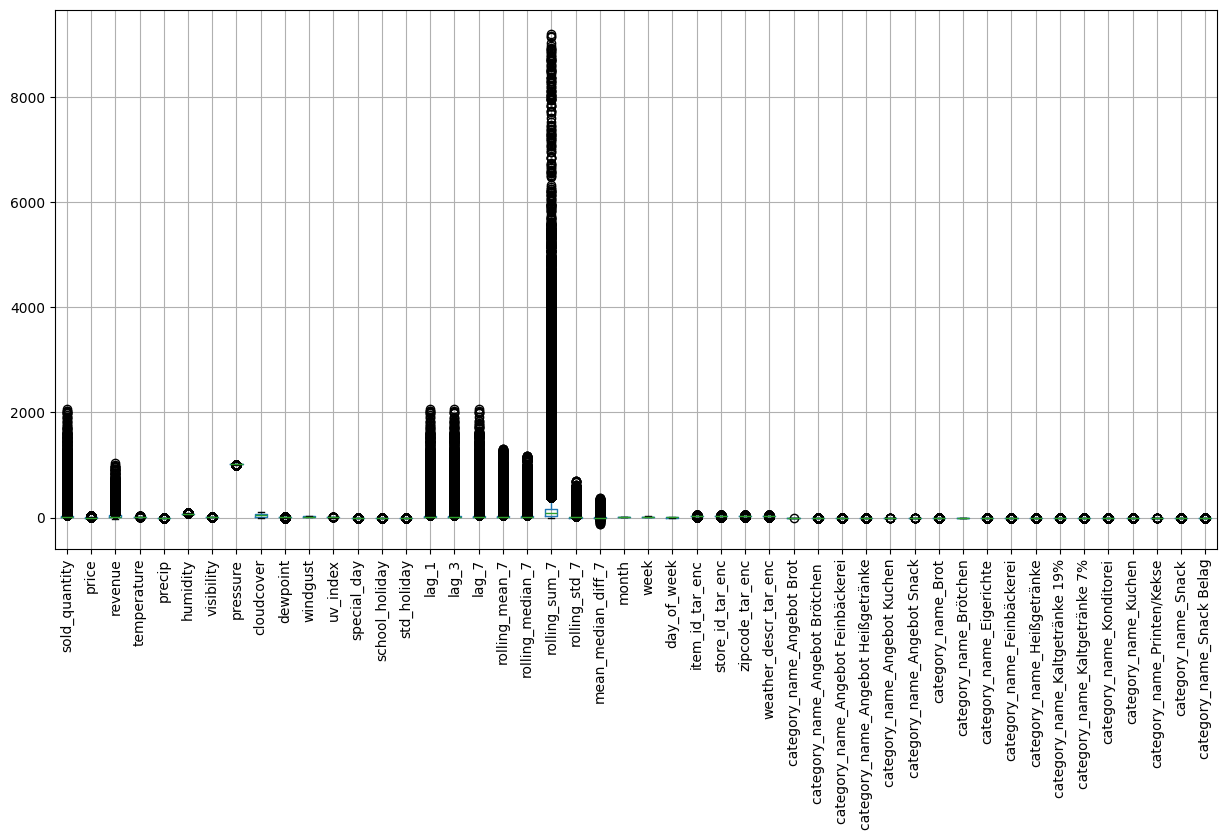

In [31]:

# check
plt.figure(figsize=(15,7))
train.boxplot(rot=90)
plt.show()

## __Split explanatory data (X) and target (y)__

In [32]:
# create exploratory and target variables

# train
X_train = train.drop('sold_quantity', axis=1)
y_train = train['sold_quantity']

# test
X_test = test.drop('sold_quantity', axis=1)
y_test = test['sold_quantity']


In [33]:
X_train.head()

,price,revenue,temperature,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc,store_id_tar_enc,zipcode_tar_enc,weather_descr_tar_enc,category_name_Angebot Brot,category_name_Angebot Brötchen,category_name_Angebot Feinbäckerei,category_name_Angebot Heißgetränke,category_name_Angebot Kuchen,category_name_Angebot Snack,category_name_Brot,category_name_Brötchen,category_name_Eigerichte,category_name_Feinbäckerei,category_name_Heißgetränke,category_name_Kaltgetränke 19%,category_name_Kaltgetränke 7%,category_name_Konditorei,category_name_Kuchen,category_name_Printen/Kekse,category_name_Snack,category_name_Snack Belag
2,0.90,9.90,8.250000,0.000000,75.375000,9.0,1027.833333,33.083333,3.916667,13.500000,2.208333,0.0,0.0,0.0,7.0,5.0,6.0,12.000000,7.0,84.0,12.649111,5.000000,4,15,3,10.000000,10.000000,10.000000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.90,12.60,10.375000,0.000000,69.625000,10.0,1022.375000,8.291667,4.458333,10.208333,2.500000,0.0,0.0,0.0,11.0,13.0,8.0,12.714286,8.0,89.0,12.392394,4.714286,4,15,4,10.333333,10.333333,10.333333,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.81,4.05,14.208333,0.004167,60.583333,10.0,1012.000000,12.041667,6.291667,21.583333,2.916667,0.0,1.0,0.0,14.0,7.0,5.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,5,11.250000,11.250000,11.250000,10.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.95,17.10,13.583333,0.000000,70.583333,10.0,1006.291667,74.708333,8.458333,29.208333,2.250000,1.0,1.0,0.0,5.0,11.0,40.0,13.571429,11.0,95.0,12.218253,2.571429,4,15,6,10.000000,10.000000,10.000000,10.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.90,0.90,13.166667,0.000000,67.125000,10.0,1008.083333,42.375000,6.500000,13.166667,2.583333,0.0,1.0,0.0,18.0,14.0,5.0,10.428571,11.0,73.0,4.961759,-0.571429,4,16,0,11.333333,11.333333,11.333333,10.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## __Scaling train data__

In [34]:
# scaling X

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)




In [35]:
# check
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(118356, 47) (118356,)
(23460, 47) (23460,)


In [36]:
# check

X_train_scaled.head(20)

,price,revenue,temperature,precip,humidity,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,lag_1,lag_3,lag_7,rolling_mean_7,rolling_median_7,rolling_sum_7,rolling_std_7,mean_median_diff_7,month,week,day_of_week,item_id_tar_enc,store_id_tar_enc,zipcode_tar_enc,weather_descr_tar_enc,category_name_Angebot Brot,category_name_Angebot Brötchen,category_name_Angebot Feinbäckerei,category_name_Angebot Heißgetränke,category_name_Angebot Kuchen,category_name_Angebot Snack,category_name_Brot,category_name_Brötchen,category_name_Eigerichte,category_name_Feinbäckerei,category_name_Heißgetränke,category_name_Kaltgetränke 19%,category_name_Kaltgetränke 7%,category_name_Konditorei,category_name_Kuchen,category_name_Printen/Kekse,category_name_Snack,category_name_Snack Belag
2,-0.376471,-0.271802,-1.166667,0.000000,0.531250,-1.000000,1.427746,-0.155835,-0.637363,-0.446281,-0.133333,0.0,0.0,0.0,-0.20,-0.30,-0.25,-0.007143,-0.222222,-0.007143,0.901301,1.523810,-1.0,-1.0,0.00,-15.531738,-15.615209,-15.619273,-17.512698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.376471,-0.193314,-0.600000,0.000000,-0.007812,0.000000,0.670520,-0.571628,-0.494505,-0.772727,0.333333,0.0,0.0,0.0,0.00,0.10,-0.15,0.028571,-0.166667,0.028571,0.871596,1.428571,-1.0,-1.0,0.25,-15.315329,-15.394945,-15.398915,-16.197399,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.411765,-0.441860,0.422222,0.045455,-0.855469,0.000000,-0.768786,-0.508735,-0.010989,0.355372,1.000000,0.0,1.0,0.0,0.15,-0.20,-0.30,0.071429,0.000000,0.071429,0.851445,0.714286,-1.0,-1.0,0.50,-14.720202,-14.789217,-14.792933,-15.320533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.356863,-0.062500,0.255556,0.000000,0.082031,0.000000,-1.560694,0.542278,0.560440,1.111570,-0.066667,1.0,1.0,0.0,-0.30,0.00,1.45,0.071429,0.000000,0.071429,0.851445,0.714286,-1.0,-1.0,0.75,-15.531738,-15.615209,-15.619273,-15.320533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.376471,-0.533430,0.144444,0.000000,-0.242187,0.000000,-1.312139,0.000000,0.043956,-0.479339,0.466667,0.0,1.0,0.0,0.35,0.15,-0.30,-0.085714,0.000000,-0.085714,0.011781,-0.333333,-1.0,-0.8,-0.75,-14.666100,-14.734151,-14.737844,-15.320533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,-0.376471,-0.193314,0.333333,0.590909,0.605469,0.000000,-2.479769,0.113906,0.868132,0.665289,0.466667,0.0,1.0,0.0,-0.50,-0.30,0.10,-0.114286,0.000000,-0.114286,0.113773,-0.523810,-1.0,-0.8,-0.50,-15.624485,-15.709608,-15.713711,-16.855048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,-0.376471,-0.376453,-0.633333,0.045455,-0.015625,0.000000,-1.028902,0.506639,-0.395604,-0.202479,-0.533333,0.0,1.0,0.0,0.15,0.35,-0.20,-0.107143,0.000000,-0.107143,0.125460,-0.476190,-1.0,-0.8,-0.25,-15.288277,-15.367411,-15.371371,-15.539750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-0.419608,-0.375872,-1.333333,1.363636,1.308594,-1.416667,-0.375723,0.698812,-0.296703,-0.260331,-1.200000,1.0,1.0,0.0,-0.20,-0.50,0.00,-0.107143,0.000000,-0.107143,0.125460,-0.476190,-1.0,-0.8,0.00,-15.531738,-15.615209,-15.619273,-15.868574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,-0.356863,-0.338663,-1.133333,0.181818,0.640625,0.000000,-0.502890,0.238994,-0.571429,-0.194215,-0.400000,0.0,1.0,1.0,-0.15,0.15,0.15,-0.128571,-0.166667,-0.128571,0.128235,0.380952,-1.0,-0.8,0.25,-15.661584,-15.747368,-15.751487,-15.445800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,-0.376471,-0.454942,-0.777778,0.000000,0.222656,0.000000,-1.040462,0.238994,-0.428571,0.367769,-0.200000,1.0,1.0,0.0,-0.15,-0.20,-0.30,-0.171429,-0.166667,-0.171429,0.091237,0.095238,-1.0,-0.8,0.50,-15.767821,-15.855498,-15.859662,-15.621956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## __Model Selection__

In [37]:
import xgboost
import lightgbm
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

In [38]:
from lazypredict import LazyRegressor
import tqdm

### Naive Baseline (lags)

In [39]:
# naive baseline models for benchmark

baseline_cols = ['lag_1', 'lag_3', 'lag_7']

def baseline_metric(X_test_scaled, y_test, baseline_cols):
    '''creating MAE and RMSE for baseline model'''
    for col in baseline_cols:
        without_NaN = X_test_scaled[col].notna()
        y_true = y_test[without_NaN]
        y_pred = X_test_scaled.loc[without_NaN, col]

        print(f'{col} Baseline:')
        print('MAE:', mean_absolute_error(y_true, y_pred))
        print('RMSE:', np.sqrt(mean_squared_error(y_true, y_pred)))
        print('-'*30)


# # lag 7
# print('Lag 7 Baseline')
# print('MAE:', mean_absolute_error(y_test, X_test_scales['lag_7']))
# print('RMSE:', np.sqrt(mean_squared_error(y_test, X_test_scaled['lag_7'])))

#print('Baselines:\nX_train_scaled, y_train:\n')
#baseline_metric(X_train_scaled, y_train, baseline_cols)

print('Baselines\nX_test_scaled, y_test:\n')
baseline_metric(X_test_scaled, y_test, baseline_cols)


Baselines
X_test_scaled, y_test:

lag_1 Baseline:
MAE: 34.48040001918159
RMSE: 105.31078008256965
------------------------------
lag_3 Baseline:
MAE: 34.49789417519181
RMSE: 105.4481416810341
------------------------------
lag_7 Baseline:
MAE: 34.46196647485081
RMSE: 104.75168758358218
------------------------------


In [40]:
# reset indices , to be in sync again

X_train_scaled = X_train_scaled.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test_scaled = X_test_scaled.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [41]:
# check
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(118356, 47) (118356,)
(23460, 47) (23460,)


In [42]:
# reduce data amount for Lazypredict
shrink_factor = 0.15

# reducing training data
X_train_idx = int(np.floor(X_train_scaled.shape[0] * shrink_factor))
y_train_idx = int(np.floor(y_train.shape[0] * shrink_factor))

print(X_train_idx, y_train_idx)

X_train_scaled_lazy = X_train_scaled[: X_train_idx]
y_train_lazy = y_train[: y_train_idx]



# reducing test data
X_test_idx = int(np.floor(X_test_scaled.shape[0] * shrink_factor))
y_test_idx = int(np.floor(y_test.shape[0] * shrink_factor))

print(X_test_idx, y_test_idx)

X_test_scaled_lazy = X_test_scaled[: X_test_idx]
y_test_lazy = y_test[: y_test_idx]



17753 17753
3519 3519


In [43]:
# check
print(X_train_scaled_lazy.shape, y_train_lazy.shape)
print(X_test_scaled_lazy.shape, y_test_lazy.shape)

(17753, 47) (17753,)
(3519, 47) (3519,)


### LazyRegressor

In [44]:
#lazy_reg = LazyRegressor(verbose=1, ignore_warnings=True, predictions=True, random_state=42)

#models, predictions = lazy_reg.fit(X_train_scaled_lazy, X_test_scaled_lazy, y_train_lazy, y_test_lazy)



  0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
#print(models)

### __Models 1st try__

In [85]:
# classifier to compare

models = {
    'Xgboost': xgboost.XGBRegressor(tree_method='hist', enable_categorical=False, random_state=42),
    'LightGbm': lightgbm.LGBMRegressor(n_estimators=1000, subsample_for_bin=100000, random_state=42, metric='rmse'),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
    #'RandomForest': RandomForestRegressor(random_state=42)
}



In [86]:
# function to compare models

def compare_models(models, train_data, train_target, test_data, test_target):
    i = 1
    num_models = len(models)
    
    for model_name, model in models.items():
        
        print(f'({i}/{num_models}): {model_name}:')
        
        reg = model
        reg.fit(train_data, train_target)
        y_pred = reg.predict(test_data)
        
        print('MAE:', mean_absolute_error(test_target, y_pred))
        print('RMSE:', np.sqrt(mean_squared_error(test_target, y_pred)))
        print()

        ## --- shap ----
        
        print(f'SHAP values for {model_name}:\n')
        
        # sampling down for shap
        sample_size = 10000
        idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)
        X_train_scaled_sample = X_train_scaled.iloc[idx]

        # getting shap values
        explainer = shap.TreeExplainer(reg)
        shap_values = explainer(X_train_scaled_sample)

        # shap plots
        #fig, ax = plt.subplots(1, 2, figsize=(15,5), dpi=400)

        # feature_importance
        #plt.sca(ax[0])
        shap.plots.bar(shap_values, show=True, max_display=20)
        #ax[0].tick_params(labelsize=8)
        #plt.title(f'Feature Importance {model_name}')
        #for text in ax[0].texts:
        #    text.set_fontsize(8)
        
        # Beeswarm
        #plt.sca(ax[1])
        shap.plots.beeswarm(shap_values, show=True, max_display=20)
        #ax[1].tick_params(labelsize=8)
        #plt.title(f'Beeswarm {model_name}')#

        ##fig.subplots_adjust(wspace=0.3)#

        ##plt.tight_layout(pad=5)
        #plt.show()
        #plt.close('all')

        i += 1
        print('--'*40)
        

### Model Interpretability - **SHAP**

### __With__ variable revenue (MAE, RMSE, SHAP)

performance with revenue:

(1/3): Xgboost:
MAE: 2.733264128783931
RMSE: 17.286185872450503

SHAP values for Xgboost:



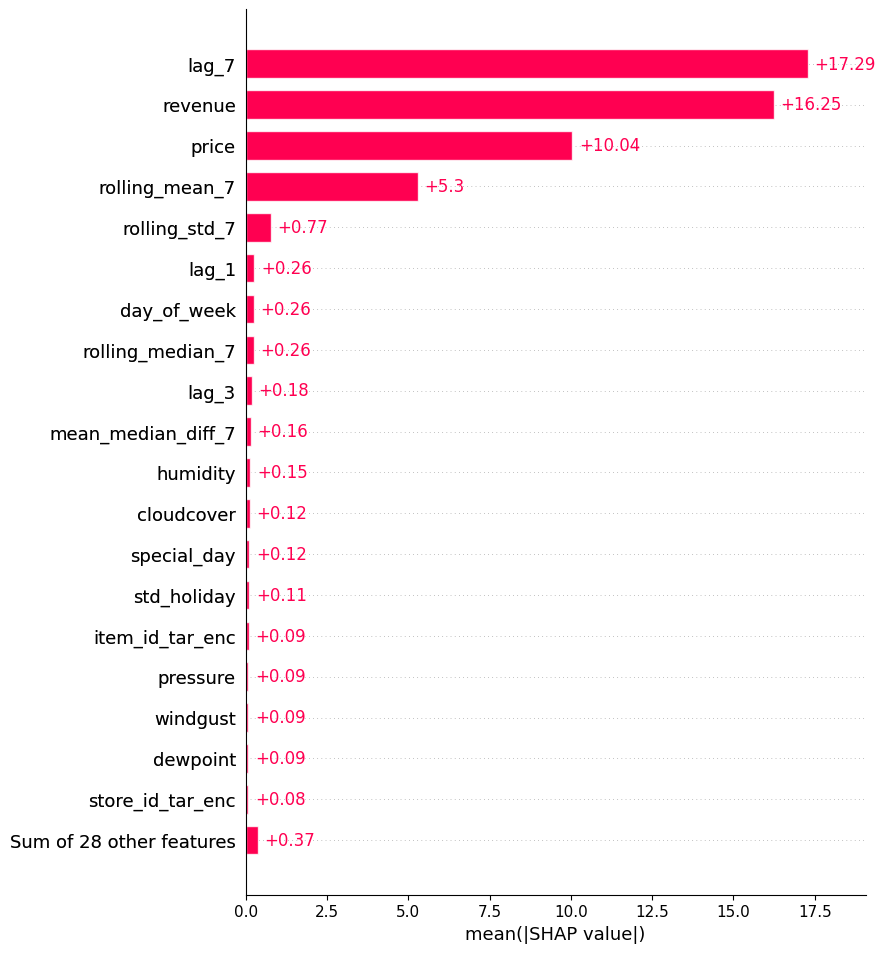

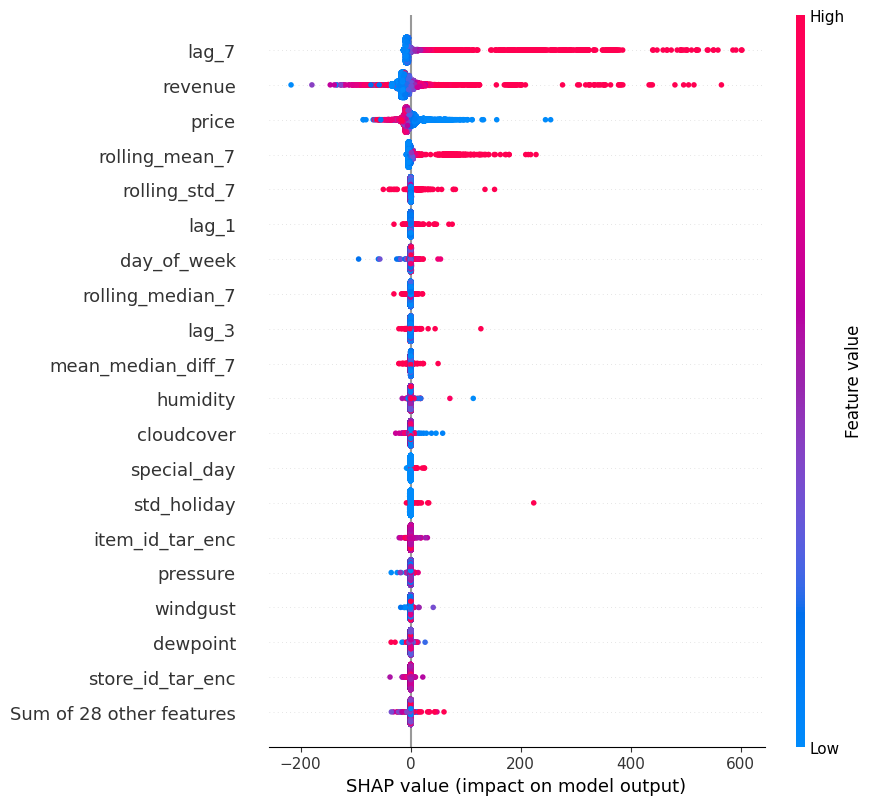

--------------------------------------------------------------------------------
(2/3): LightGbm:
MAE: 1.9146255158229
RMSE: 13.034302355927084

SHAP values for LightGbm:



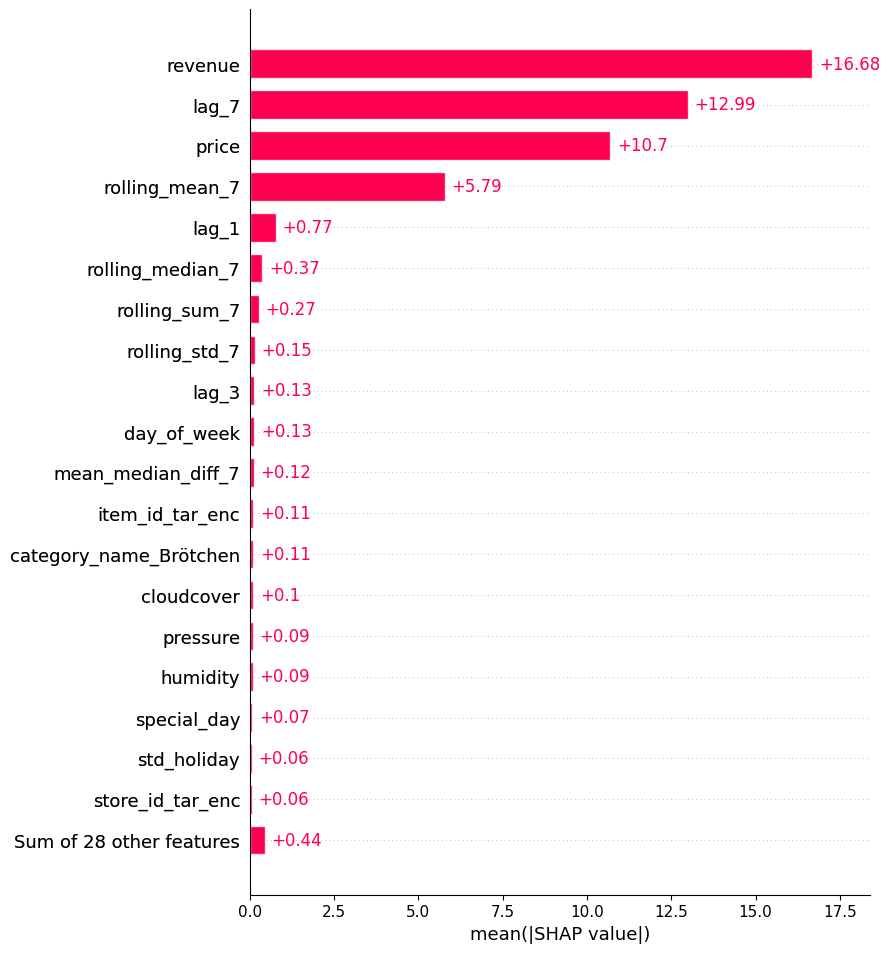

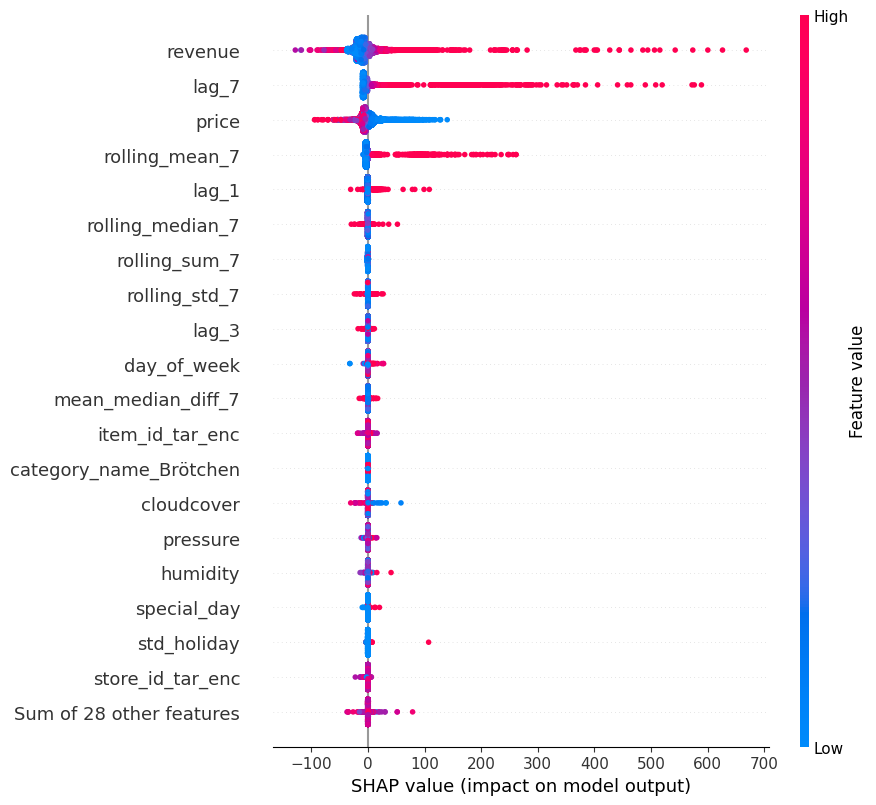

--------------------------------------------------------------------------------
(3/3): GradientBoosting:
MAE: 4.008188887625976
RMSE: 9.44686618494596

SHAP values for GradientBoosting:



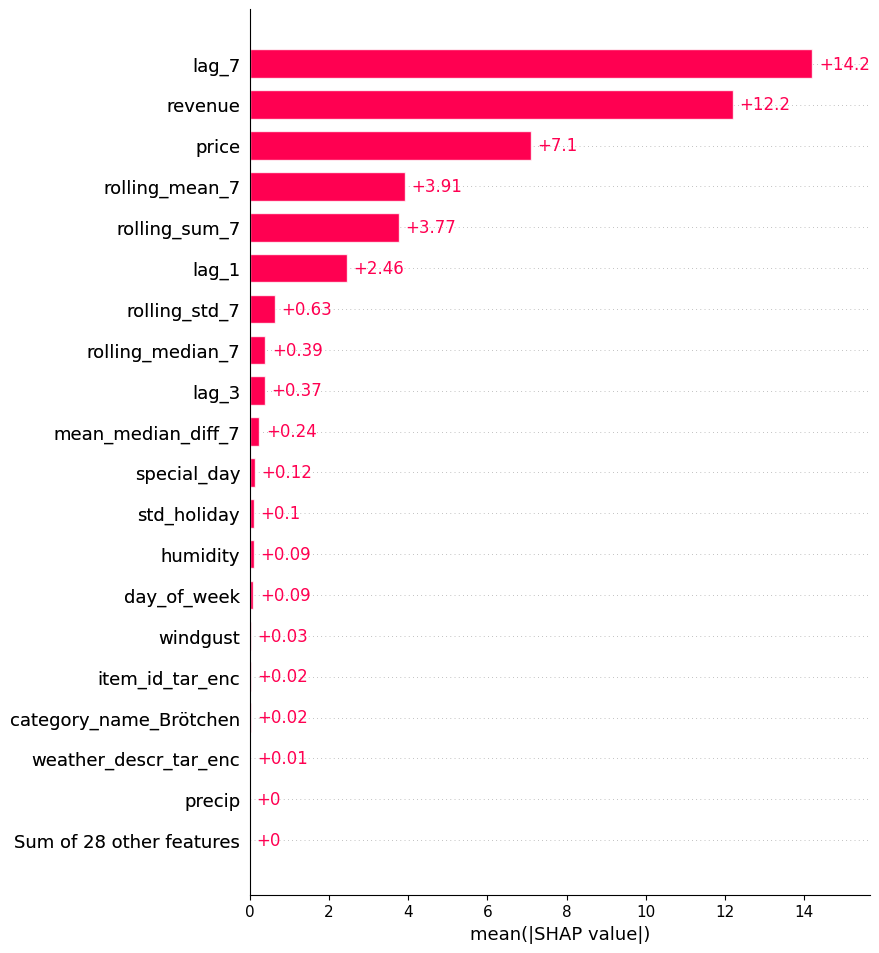

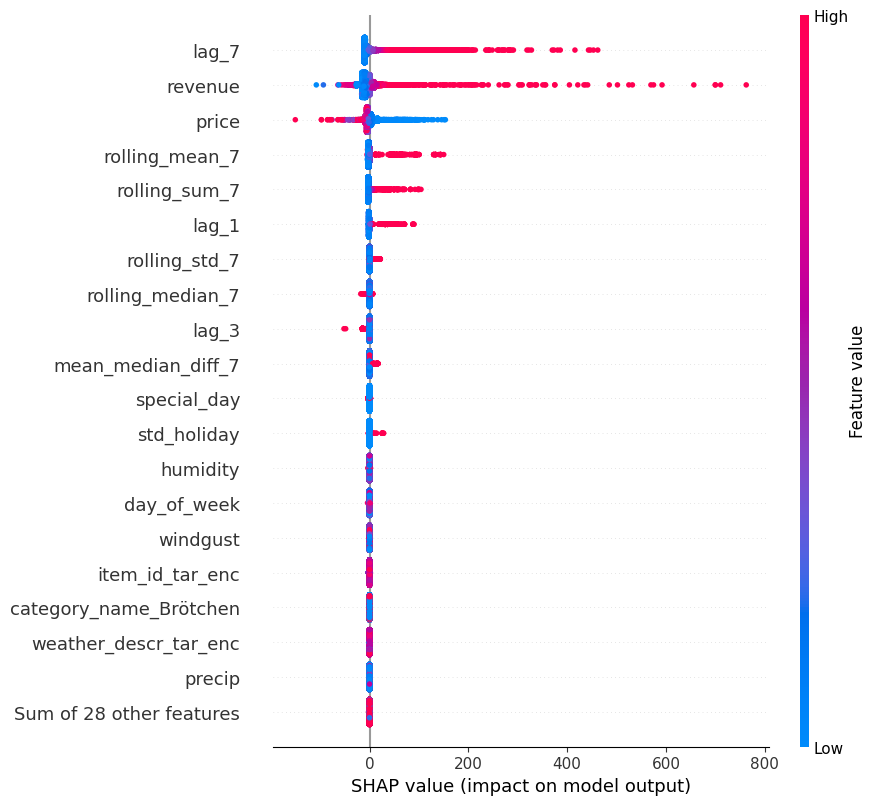

--------------------------------------------------------------------------------


In [87]:
print('performance with revenue:')
print()
compare_models(models, X_train_scaled, y_train, X_test_scaled, y_test)

### __Without__ variable revenue

In [89]:
X_train_scaled = X_train_scaled.drop('revenue', axis=1, errors='ignore')
X_test_scaled = X_test_scaled.drop('revenue', axis=1, errors='ignore')
#X_train_scaled.head()

performance WITHOUT revenue:

(1/3): Xgboost:
MAE: 9.373182991709125
RMSE: 28.735081089543513

SHAP values for Xgboost:



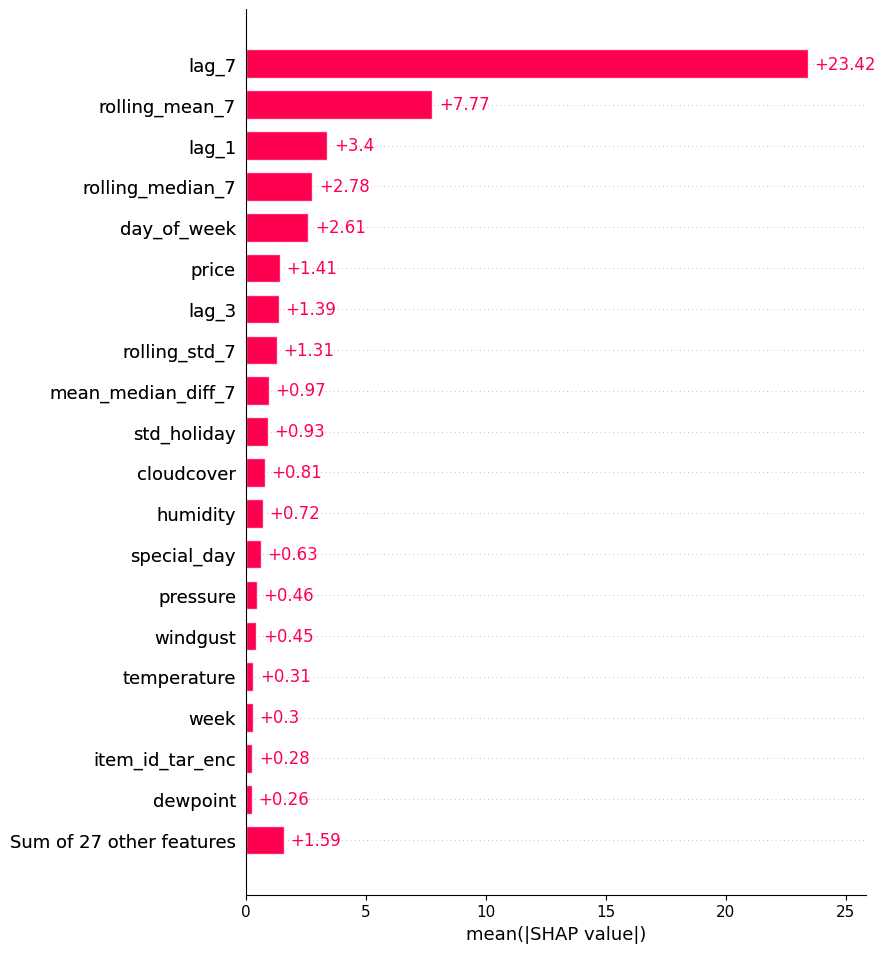

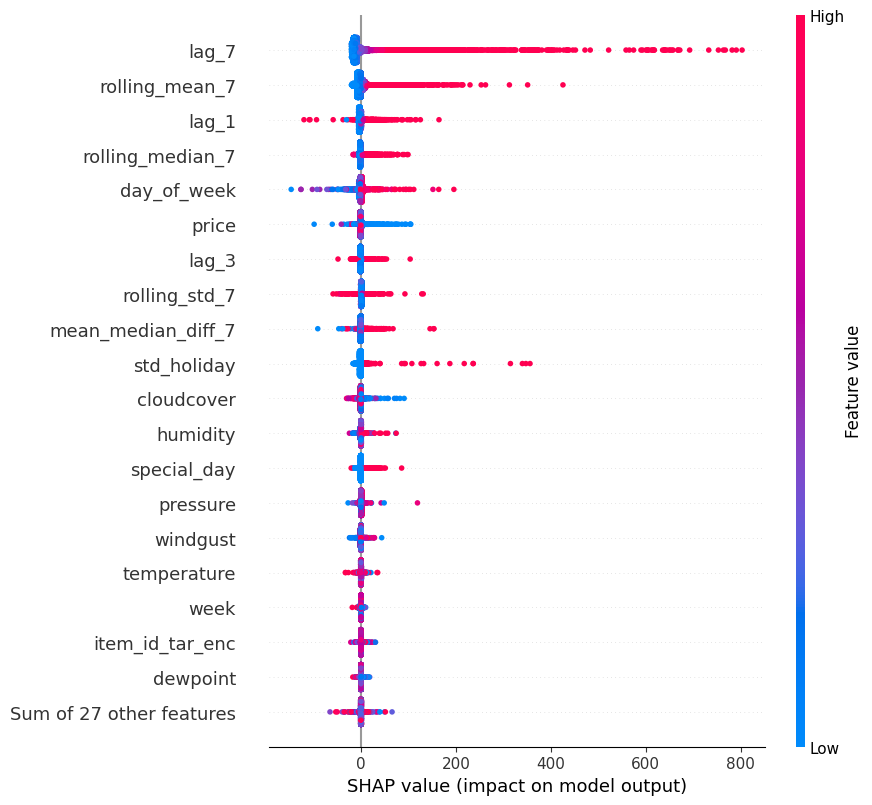

--------------------------------------------------------------------------------
(2/3): LightGbm:
MAE: 8.664767468943332
RMSE: 26.856593218638903

SHAP values for LightGbm:



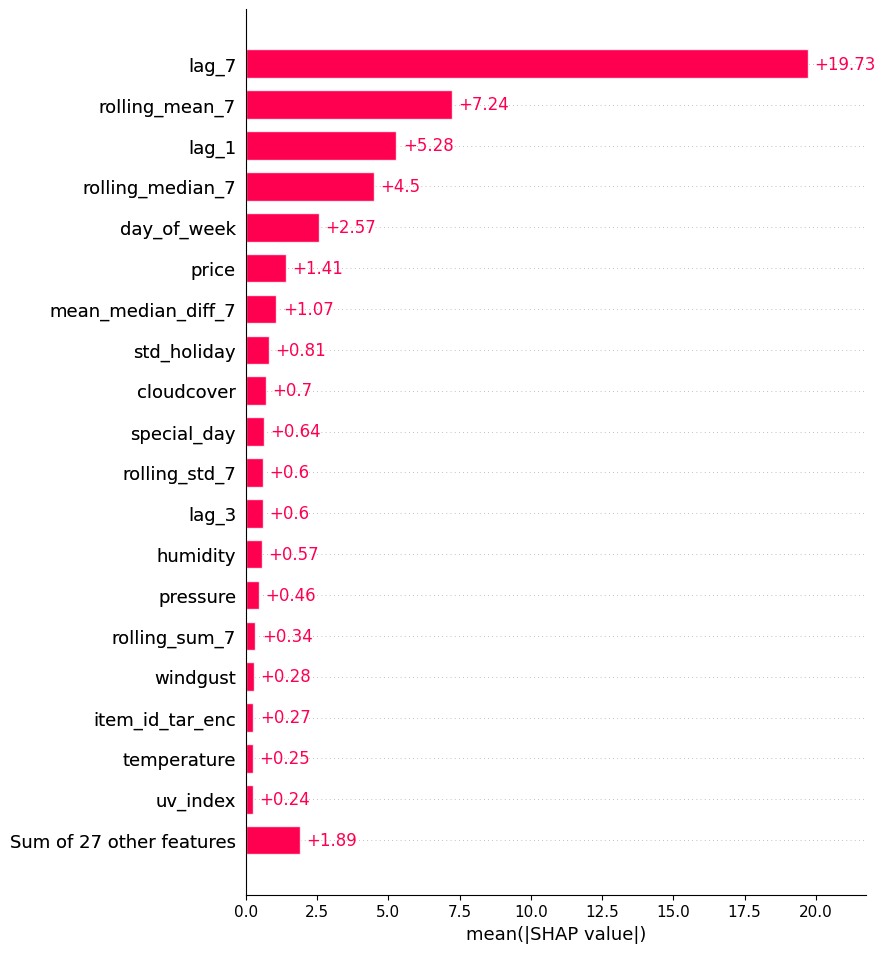

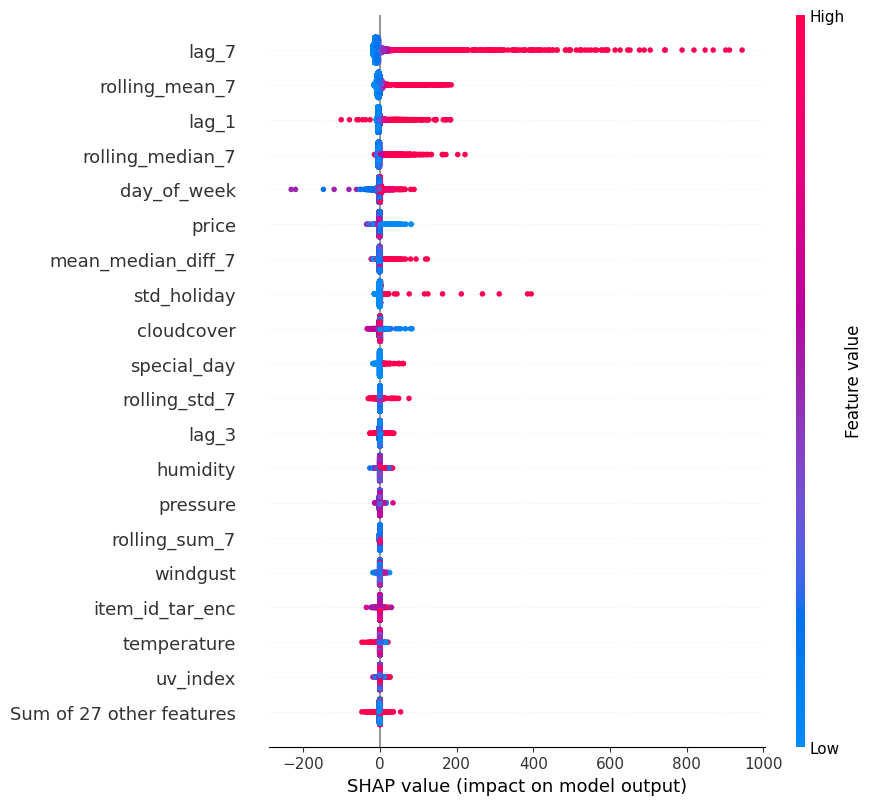

--------------------------------------------------------------------------------
(3/3): GradientBoosting:
MAE: 8.51720842890224
RMSE: 27.01704625457563

SHAP values for GradientBoosting:



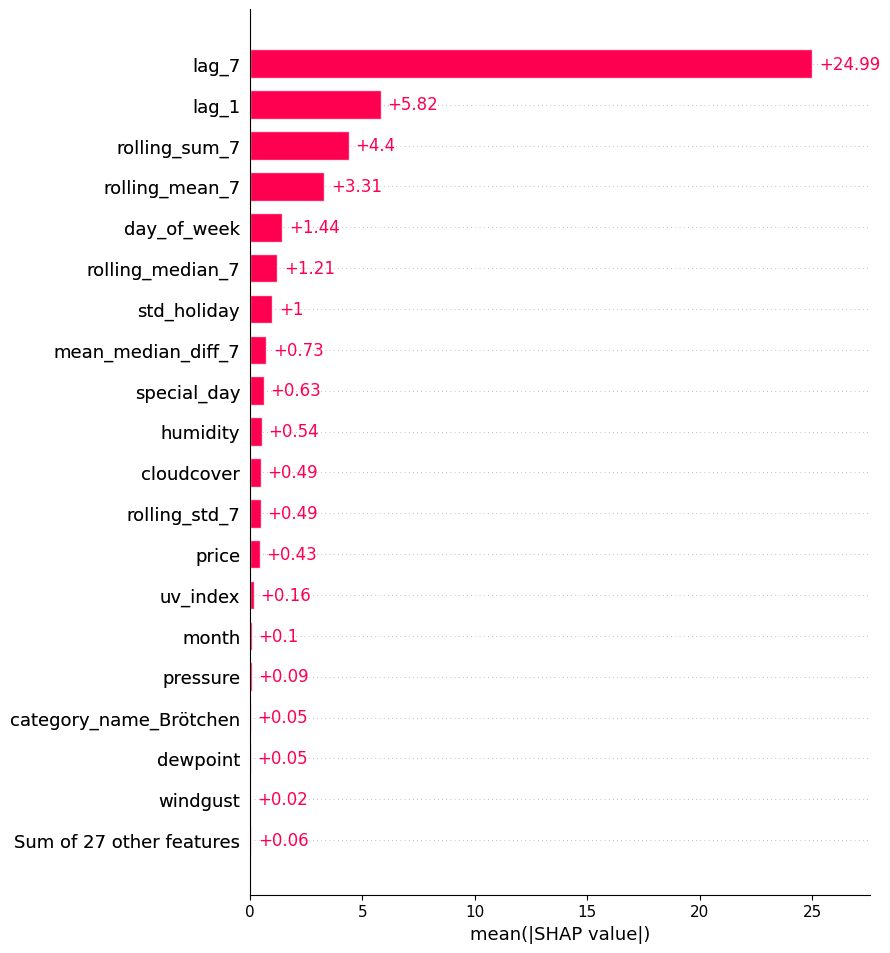

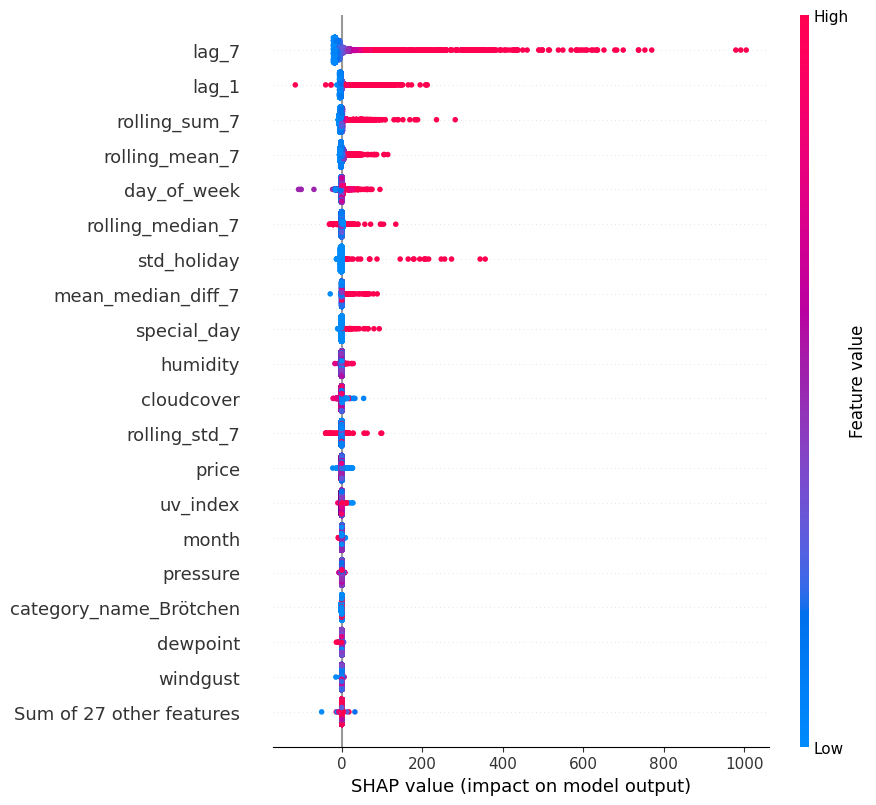

--------------------------------------------------------------------------------


In [90]:
print('performance WITHOUT revenue:\n')
compare_models(models, X_train_scaled, y_train, X_test_scaled, y_test)

### XGBoost

In [45]:
# xgboost 
xgb = xgboost.XGBRegressor(tree_method='hist', enable_categorical=False)
xgb.fit(X_train_scaled, y_train)




,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [46]:
y_pred_xgb = xgb.predict(X_test_scaled)
print('XGBoost:')
print('MAE:', mean_absolute_error(y_test, y_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost:
MAE: 2.733264128783931
RMSE: 17.286185872450503


### LightGBM

In [47]:
# lightgbm
lgb = lightgbm.LGBMRegressor(n_estimators=1000, subsample_for_bin=100000, random_state=42, metric='rmse')
lgb.fit(X_train_scaled, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,1000
,subsample_for_bin,100000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
y_pred_lgb = lgb.predict(X_test_scaled)
print('LighGBM Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_lgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lgb)))

print()

y_pred_lgb_train = lgb.predict(X_train_scaled)
print('LighGBM Train:')
print('MAE:', mean_absolute_error(y_train, y_pred_lgb_train))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_lgb_train)))



LighGBM Test:
MAE: 1.9146255158229
RMSE: 13.034302355927084

LighGBM Train:
MAE: 0.5447599680441241
RMSE: 1.337028436135666


In [49]:
# LightGBM:
# MAE: 0.20288126272325116
# RMSE: 3.2958418891273156

# LighGBM:
# MAE: 0.1459244602906927
# RMSE: 3.3463232821532256

### Gradient Boost

In [54]:
# gradient boost
from sklearn.ensemble import GradientBoostingRegressor



In [55]:
gb = GradientBoostingRegressor()
gb.fit(X_train_scaled, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [56]:
y_pred_gb = gb.predict(X_test_scaled)
print('Gradient Boost Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_gb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_gb)))

print()

y_pred_gb_train = gb.predict(X_train_scaled)
print('Gradient Boost Train:')
print('MAE:', mean_absolute_error(y_train, y_pred_gb_train))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_gb_train)))

Gradient Boost Test:
MAE: 4.008206002107901
RMSE: 9.41319456647709

Gradient Boost Train:
MAE: 3.506754726397184
RMSE: 7.316239239638345


### RandomForest

In [43]:
# RandomForest
rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
y_pred_rf = rf.predict(X_test_scaled)
print('RandomForest Test:')
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RandomForest Test:
MAE: 8.220538798380222
RMSE: 25.269474506143165


# __weather__

In [50]:
# df_weather = pd.read_parquet('20260317_121949_weather.parquet', 
#                              engine='fastparquet', 
#                              columns=['date', 'time', 'zipcode', 'temperature', 'wind_speed', 'wind_degree',
#        'wind_dir', 'weather_code', 'weather_description', 'precip', 'humidity',
#        'visibility', 'pressure', 'cloudcover', 'heatindex', 'dewpoint',
#        'windchill', 'windgust', 'feelslike', 'uv_index']
#                              )
# #print(df_weather.columns)
# df_weather_10k = df_weather.sample(10000)

In [51]:
# weather_corr = df_weather_10k.corr(numeric_only=True).abs()
# plt.figure(figsize=(12,6))
# cols_temp = ['temperature', 'feelslike', 'windchill', 'heatindex']
# sns.heatmap(weather_corr, annot=True, vmin=0.5, vmax=0.99, center=0.7)
# plt.tight_layout()
# plt.show()

# cols_to_keep = ['feelslike', 'wind_gust', 'weather_code', 'precip', 'humidity', 'visibility', 'pressure', 'cloudcover', 'uv_index']
# cols_to_del = ['temperature',  'windchill', 'heatindex', 'wind_speed', 'dewpoint',]


In [52]:
# remaining weather cols 
# df_weather = df_weather.drop(columns=cols_to_del)